# EDA dữ liệu giao dịch đã làm sạch

Notebook này phân tích tập dữ liệu giao dịch sau làm sạch trong `data/processed/clean_data.csv`. Mục tiêu của bước EDA là hiểu dữ liệu đang mô tả điều gì, thị trường nào chiếm vai trò chính, và dữ liệu có đủ cơ sở để chuyển sang phân tích RFM hay không.

Mục tiêu:

- Kiểm tra nhanh chất lượng dữ liệu sạch.
- Phân tích thị trường theo quốc gia.
- Phân tích xu hướng theo thời gian, sản phẩm và khách hàng.
- Đưa ra bằng chứng để chọn United Kingdom làm scope cho RFM + GMM ở phase sau.

## 1. Load & Overview

Trước khi phân tích sâu, cần xem dữ liệu có những cột nào, quy mô bao nhiêu dòng, kéo dài trong khoảng thời gian nào và đại diện cho bao nhiêu khách hàng. Đây là phần giúp định vị nhanh phạm vi của bộ dữ liệu.

Đoạn code dưới đây import các thư viện cần thiết, đọc `data/processed/clean_data.csv`, chuyển `InvoiceDate` về kiểu thời gian và tạo thêm cột `Month` để phục vụ phân tích theo tháng.

In [64]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "clean_data.csv"

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

df = pd.read_csv(DATA_PATH)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")
df["Month"] = df["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12-01


Bảng dưới đây tóm tắt quy mô dữ liệu sau làm sạch. Các chỉ số như số khách hàng, số hóa đơn, số quốc gia và tổng doanh thu sẽ được dùng làm nền cho các phân tích tiếp theo.

Đoạn code dưới đây tạo bảng tổng quan về quy mô dữ liệu, gồm số dòng, số cột, số khách hàng, số hóa đơn, số quốc gia, số sản phẩm, tổng doanh thu và khoảng thời gian dữ liệu.

In [65]:
overview = pd.DataFrame(
    {
        "Metric": [
            "Rows",
            "Columns",
            "Customers",
            "Invoices",
            "Countries",
            "Products",
            "Total Revenue",
            "Start Date",
            "End Date",
        ],
        "Value": [
            f"{df.shape[0]:,}",
            f"{df.shape[1]:,}",
            f"{df['CustomerID'].nunique():,}",
            f"{df['InvoiceNo'].nunique():,}",
            f"{df['Country'].nunique():,}",
            f"{df['StockCode'].nunique():,}",
            f"£{df['TotalPrice'].sum():,.2f}",
            df["InvoiceDate"].min().strftime("%Y-%m-%d"),
            df["InvoiceDate"].max().strftime("%Y-%m-%d"),
        ],
    }
)

overview

,Metric,Value
0,Rows,"391,150"
1,Columns,10
2,Customers,"4,334"
3,Invoices,"18,402"
4,Countries,37
5,Products,"3,659"
6,Total Revenue,"£8,737,227.64"
7,Start Date,2010-12-01
8,End Date,2011-12-09


Tiếp theo là kiểm tra kiểu dữ liệu, số lượng giá trị thiếu và số lượng giá trị khác nhau ở từng cột. Việc này giúp phát hiện sớm các cột bị parse sai hoặc còn thiếu dữ liệu bất thường.

Đoạn code dưới đây kiểm tra từng cột về kiểu dữ liệu, số giá trị thiếu và số giá trị khác nhau. Bảng này giúp phát hiện nhanh cột nào có vấn đề trước khi phân tích sâu.

In [66]:
pd.DataFrame(
    {
        "Column": df.columns,
        "Dtype": [str(dtype) for dtype in df.dtypes],
        "Missing Values": df.isna().sum().values,
        "Unique Values": [df[col].nunique() for col in df.columns],
    }
)

,Column,Dtype,Missing Values,Unique Values
0,InvoiceNo,int64,0,18402
1,StockCode,str,0,3659
2,Description,str,0,3860
3,Quantity,int64,0,299
4,InvoiceDate,datetime64[us],0,17166
5,UnitPrice,float64,0,355
6,CustomerID,int64,0,4334
7,Country,str,0,37
8,TotalPrice,float64,0,2620
9,Month,datetime64[us],0,13


## 2. Cleaning Validation

Dữ liệu giao dịch thực tế thường có hóa đơn hủy, số lượng âm, đơn giá bằng 0, khách hàng không có mã định danh hoặc dòng bị trùng. Với bài toán RFM, các lỗi này có thể làm sai cả Recency, Frequency và Monetary của khách hàng, nên cần kiểm tra lại trước khi phân tích.

Đoạn code dưới đây kiểm tra lại các lỗi thường gặp trong dữ liệu giao dịch, như hóa đơn hủy, giá trị âm, dữ liệu trùng và sai lệch giữa `TotalPrice` với `Quantity * UnitPrice`.

In [67]:
total_price_diff = (df["TotalPrice"] - df["Quantity"] * df["UnitPrice"]).abs()

validation = pd.DataFrame(
    {
        "Check": [
            "Missing CustomerID",
            "Duplicate rows",
            "Cancelled invoices starting with C",
            "Quantity <= 0",
            "UnitPrice <= 0",
            "TotalPrice <= 0",
            "InvoiceDate parse errors",
            "TotalPrice != Quantity * UnitPrice",
        ],
        "Count": [
            int(df["CustomerID"].isna().sum()),
            int(df.duplicated().sum()),
            int(df["InvoiceNo"].astype(str).str.startswith("C").sum()),
            int((df["Quantity"] <= 0).sum()),
            int((df["UnitPrice"] <= 0).sum()),
            int((df["TotalPrice"] <= 0).sum()),
            int(df["InvoiceDate"].isna().sum()),
            int((total_price_diff > 0.01).sum()),
        ],
    }
)

validation

,Check,Count
0,Missing CustomerID,0
1,Duplicate rows,0
2,Cancelled invoices starting with C,0
3,Quantity <= 0,0
4,UnitPrice <= 0,0
5,TotalPrice <= 0,0
6,InvoiceDate parse errors,0
7,TotalPrice != Quantity * UnitPrice,0


**Nhận xét:** nếu các kiểm tra đều bằng 0, `data/processed/clean_data.csv` có thể được xem là nguồn dữ liệu sạch cho EDA. Điều này cũng giúp bước RFM sau đó đáng tin hơn, vì mỗi khách hàng sẽ được tổng hợp từ các giao dịch hợp lệ.

## 3. Country Market EDA

Dữ liệu có nhiều quốc gia, nên trước khi phân cụm khách hàng cần xác định thị trường nào đủ lớn và ổn định để phân tích. Phần này dùng ba thước đo chính: số hóa đơn, số khách hàng và tổng doanh thu.

Bảng tổng hợp theo quốc gia cho thấy mỗi thị trường đóng góp bao nhiêu giao dịch, bao nhiêu khách hàng và bao nhiêu doanh thu. Ngoài tổng doanh thu, phần này cũng tính tỷ trọng để dễ so sánh quy mô giữa các quốc gia.

Đoạn code dưới đây tổng hợp dữ liệu theo quốc gia để tính số hóa đơn, số khách hàng, tổng doanh thu, tỷ trọng doanh thu, tỷ trọng khách hàng, tỷ trọng giao dịch và doanh thu trung bình trên mỗi khách hàng.

In [68]:
country_summary = (
    df.groupby("Country")
    .agg(
        Transactions=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique"),
        Revenue=("TotalPrice", "sum"),
        Rows=("InvoiceNo", "size"),
    )
    .sort_values("Revenue", ascending=False)
)

country_summary["RevenueSharePct"] = country_summary["Revenue"] / country_summary["Revenue"].sum() * 100
country_summary["CustomerSharePct"] = country_summary["Customers"] / df["CustomerID"].nunique() * 100
country_summary["TransactionSharePct"] = country_summary["Transactions"] / df["InvoiceNo"].nunique() * 100
country_summary["RevenuePerCustomer"] = country_summary["Revenue"] / country_summary["Customers"]

country_overview = country_summary.reset_index()[
    ["Country", "Transactions", "Customers", "Revenue"]
].copy()
country_overview["Revenue"] = country_overview["Revenue"].round(2)

country_overview

,Country,Transactions,Customers,Revenue
0,United Kingdom,16579,3916,7242855.32
1,Netherlands,93,9,283889.34
2,EIRE,256,3,257013.12
3,Germany,443,94,205381.15
4,France,379,87,183801.94
5,Australia,56,9,138103.81
6,Spain,88,30,55706.56
7,Switzerland,47,21,52441.95
8,Japan,19,8,37416.37
9,Belgium,98,25,36927.34


Bảng tiếp theo chuyển ba chỉ số chính sang dạng tỷ trọng phần trăm. Cách nhìn này giúp thấy rõ mức độ tập trung của dữ liệu vào từng quốc gia, đặc biệt là United Kingdom.

Đoạn code dưới đây tạo bảng market share theo quốc gia, gồm tỷ trọng doanh thu, tỷ trọng khách hàng và tỷ trọng số hóa đơn.

In [69]:
country_market_share = country_summary.reset_index()[
    ["Country", "RevenueSharePct", "CustomerSharePct", "TransactionSharePct"]
].copy()

country_market_share.round(2)

,Country,RevenueSharePct,CustomerSharePct,TransactionSharePct
0,United Kingdom,82.90,90.36,90.09
1,Netherlands,3.25,0.21,0.51
2,EIRE,2.94,0.07,1.39
3,Germany,2.35,2.17,2.41
4,France,2.10,2.01,2.06
5,Australia,1.58,0.21,0.30
6,Spain,0.64,0.69,0.48
7,Switzerland,0.60,0.48,0.26
8,Japan,0.43,0.18,0.10
9,Belgium,0.42,0.58,0.53


Riêng United Kingdom được tách ra để xem tỷ trọng trên toàn bộ dữ liệu. Nếu một quốc gia chiếm phần lớn cả doanh thu, khách hàng và giao dịch, việc chọn quốc gia đó làm phạm vi phân cụm sẽ có cơ sở hơn.

Đoạn code dưới đây tách riêng tỷ trọng của United Kingdom để xem quốc gia này chiếm bao nhiêu phần trăm doanh thu, khách hàng và số hóa đơn trong toàn bộ dữ liệu.

In [70]:
uk_market_share = country_summary.loc[
    "United Kingdom",
    ["RevenueSharePct", "CustomerSharePct", "TransactionSharePct"],
]

uk_market_share.round(2)

RevenueSharePct        82.90
CustomerSharePct       90.36
TransactionSharePct    90.09
Name: United Kingdom, dtype: float64

Biểu đồ dưới đây so sánh top 10 quốc gia theo doanh thu. Đây là góc nhìn quan trọng nhất về giá trị kinh doanh, vì nó cho biết thị trường nào đang tạo ra phần lớn doanh thu cho cửa hàng.

Đoạn code dưới đây vẽ biểu đồ top 10 quốc gia theo doanh thu. Biểu đồ này cho thấy thị trường nào đóng góp giá trị bán hàng lớn nhất.

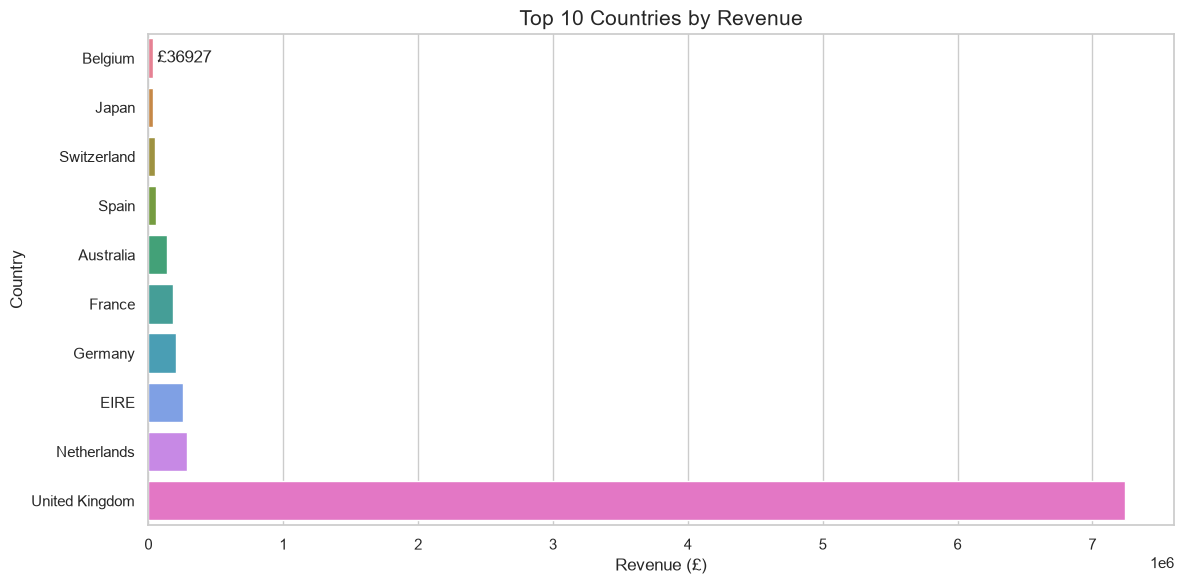

In [71]:
top_revenue_countries = country_summary.head(10).sort_values("Revenue")

ax = sns.barplot(
    data=top_revenue_countries.reset_index(),
    x="Revenue",
    y="Country",
    hue="Country",
    dodge=False,
    legend=False,
)
ax.set_title("Top 10 Countries by Revenue")
ax.set_xlabel("Revenue (£)")
ax.set_ylabel("Country")
ax.bar_label(ax.containers[0], fmt="£%.0f", padding=3)
plt.tight_layout()
plt.show()

**Nhận xét:** United Kingdom đạt doanh thu £7,242,855.32, chiếm 82.90% tổng doanh thu. Quốc gia đứng thứ hai là Netherlands với £283,889.34, thấp hơn UK rất nhiều, cho thấy doanh thu tập trung chủ yếu ở thị trường UK.

Tiếp theo là số lượng khách hàng theo quốc gia. Một thị trường có doanh thu cao nhưng quá ít khách hàng có thể chưa phù hợp để huấn luyện mô hình phân cụm riêng, vì dữ liệu không đủ đa dạng.

Đoạn code dưới đây vẽ biểu đồ top 10 quốc gia theo số lượng khách hàng. Biểu đồ này giúp đánh giá thị trường nào có quy mô khách hàng đủ lớn để phân tích hành vi.

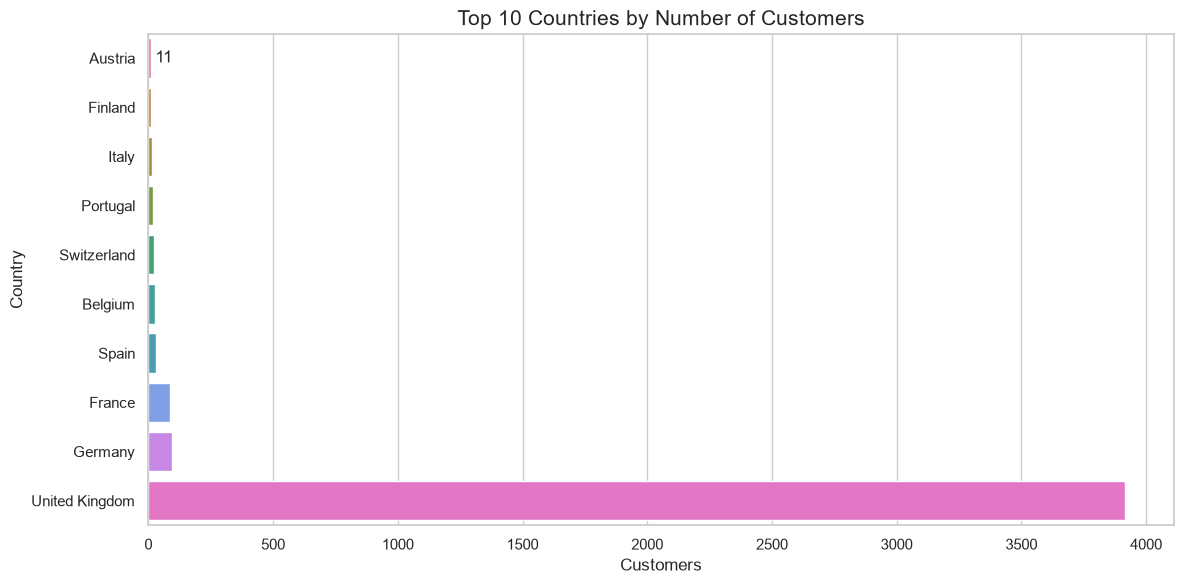

In [72]:
top_customer_countries = country_summary.sort_values("Customers", ascending=False).head(10).sort_values("Customers")

ax = sns.barplot(
    data=top_customer_countries.reset_index(),
    x="Customers",
    y="Country",
    hue="Country",
    dodge=False,
    legend=False,
)
ax.set_title("Top 10 Countries by Number of Customers")
ax.set_xlabel("Customers")
ax.set_ylabel("Country")
ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)
plt.tight_layout()
plt.show()

**Nhận xét:** United Kingdom có 3,916 khách hàng, chiếm 90.36% tổng số khách hàng. Các thị trường tiếp theo nhỏ hơn rất nhiều, như Germany có 94 khách hàng và France có 87 khách hàng.

Biểu đồ số hóa đơn giúp bổ sung góc nhìn về mức độ hoạt động của từng thị trường. Nếu một quốc gia vừa có nhiều khách vừa có nhiều hóa đơn, hành vi mua hàng ở đó sẽ ổn định hơn để phân tích RFM.

Đoạn code dưới đây vẽ biểu đồ top 10 quốc gia theo số hóa đơn. Đây là thước đo mức độ hoạt động giao dịch của từng thị trường.

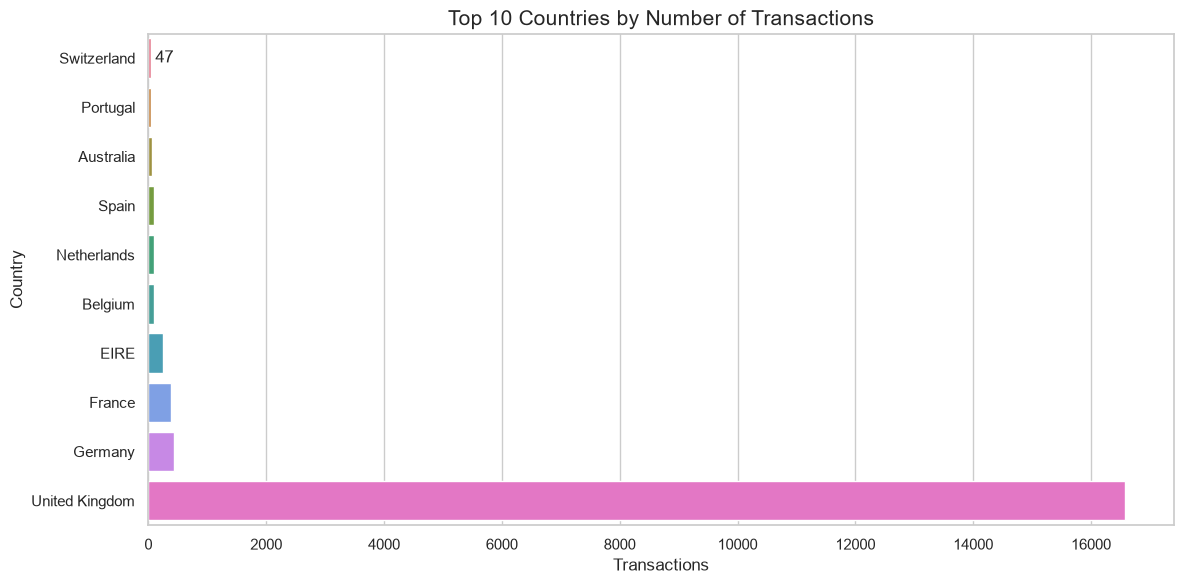

In [73]:
top_transaction_countries = country_summary.sort_values("Transactions", ascending=False).head(10).sort_values("Transactions")

ax = sns.barplot(
    data=top_transaction_countries.reset_index(),
    x="Transactions",
    y="Country",
    hue="Country",
    dodge=False,
    legend=False,
)
ax.set_title("Top 10 Countries by Number of Transactions")
ax.set_xlabel("Transactions")
ax.set_ylabel("Country")
ax.bar_label(ax.containers[0], fmt="%.0f", padding=3)
plt.tight_layout()
plt.show()

**Nhận xét:** United Kingdom có 16,579 hóa đơn, chiếm 90.09% tổng số hóa đơn. Germany đứng sau với 443 hóa đơn và France có 379 hóa đơn, khoảng cách này cho thấy UK là thị trường hoạt động thường xuyên nhất.

Doanh thu trung bình trên mỗi khách hàng giúp phát hiện các thị trường nhỏ nhưng có khách hàng giá trị cao. Chỉ số này không thay thế tổng doanh thu, nhưng cho thấy một số quốc gia ít khách vẫn có thể đáng chú ý về mặt chăm sóc khách hàng lớn.

Đoạn code dưới đây tính và vẽ doanh thu trung bình trên mỗi khách hàng theo quốc gia. Phần này giúp nhận diện các thị trường nhỏ nhưng có khách hàng giá trị cao.

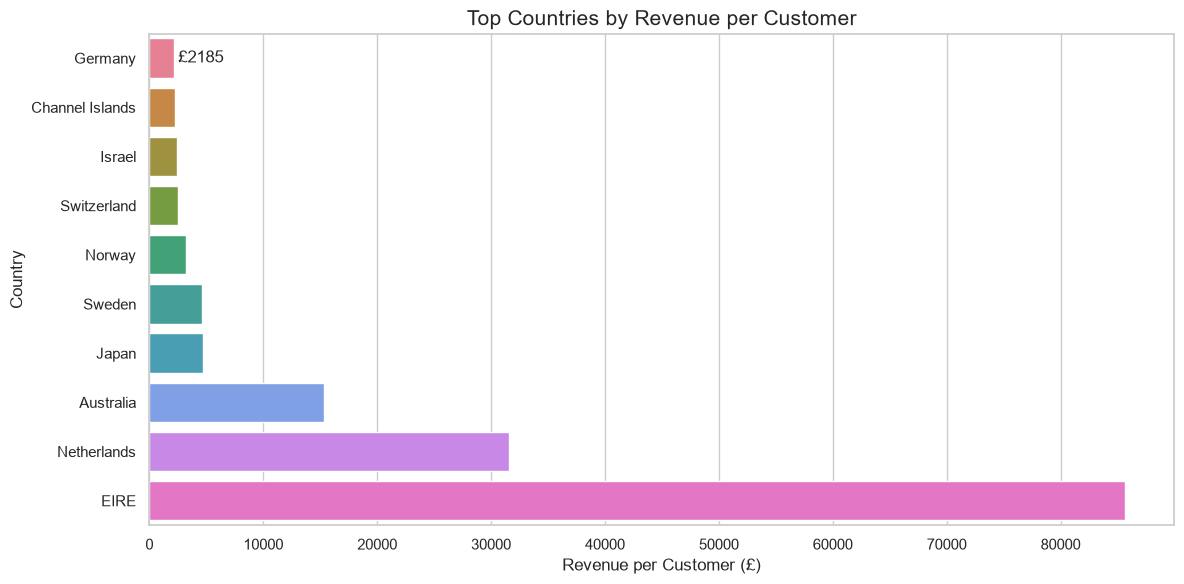

In [74]:
top_revenue_per_customer = (
    country_summary[country_summary["Customers"] >= 2]
    .sort_values("RevenuePerCustomer", ascending=False)
    .head(10)
    .sort_values("RevenuePerCustomer")
)

ax = sns.barplot(
    data=top_revenue_per_customer.reset_index(),
    x="RevenuePerCustomer",
    y="Country",
    hue="Country",
    dodge=False,
    legend=False,
)
ax.set_title("Top Countries by Revenue per Customer")
ax.set_xlabel("Revenue per Customer (£)")
ax.set_ylabel("Country")
ax.bar_label(ax.containers[0], fmt="£%.0f", padding=3)
plt.tight_layout()
plt.show()

**Nhận xét:** EIRE có doanh thu trung bình trên mỗi khách hàng cao nhất, khoảng £85,671.04, trong khi Netherlands đạt khoảng £31,543.26. United Kingdom chỉ đạt khoảng £1,849.55 mỗi khách hàng, nhưng bù lại có quy mô khách hàng lớn vượt trội.

Biểu đồ phân tán bên dưới đặt số khách hàng và doanh thu trên cùng một mặt phẳng. Kích thước điểm biểu diễn số hóa đơn, nhờ vậy có thể thấy sự khác nhau giữa thị trường lớn về quy mô và thị trường nhỏ nhưng có doanh thu cao.

Đoạn code dưới đây vẽ scatter plot giữa số khách hàng và doanh thu theo quốc gia, đồng thời dùng kích thước điểm để biểu diễn số hóa đơn. Biểu đồ này giúp so sánh quy mô thị trường trên nhiều chiều cùng lúc.

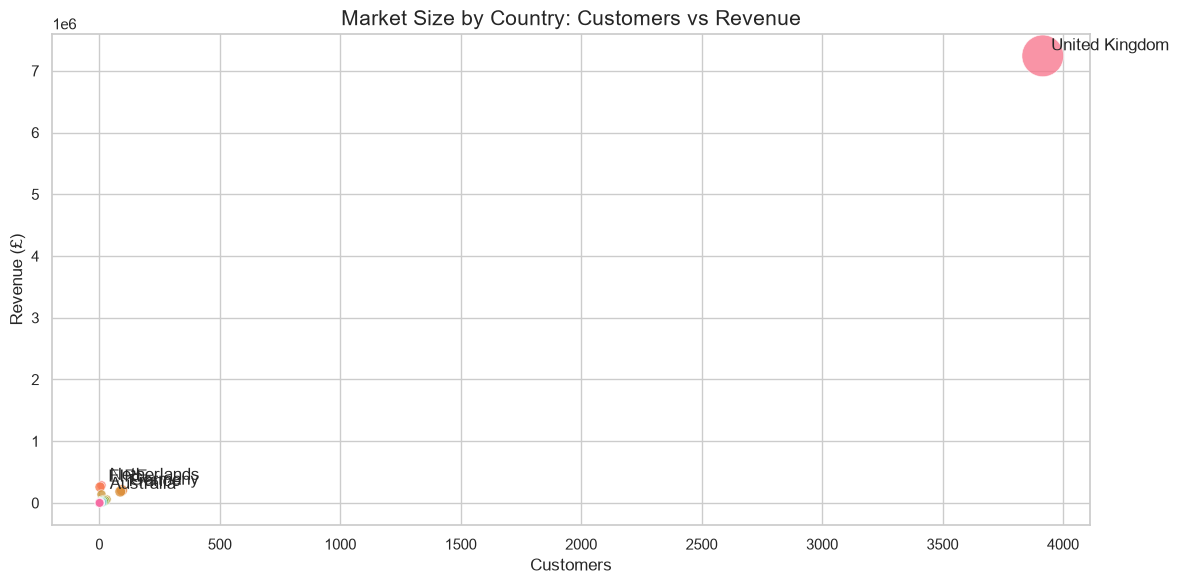

In [75]:
scatter_data = country_summary.reset_index().copy()

ax = sns.scatterplot(
    data=scatter_data,
    x="Customers",
    y="Revenue",
    size="Transactions",
    sizes=(40, 900),
    hue="Country",
    legend=False,
    alpha=0.75,
)

for _, row in scatter_data.sort_values("Revenue", ascending=False).head(6).iterrows():
    ax.annotate(row["Country"], (row["Customers"], row["Revenue"]), xytext=(6, 4), textcoords="offset points")

ax.set_title("Market Size by Country: Customers vs Revenue")
ax.set_xlabel("Customers")
ax.set_ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

**Nhận xét:** trên biểu đồ phân tán, United Kingdom nằm tách biệt ở vùng có cả số khách hàng và doanh thu cao nhất. Netherlands và EIRE có ít khách hàng hơn nhiều nhưng vẫn tạo doanh thu lớn, cho thấy đây có thể là các thị trường có khách hàng mua giá trị cao.

**Nhận xét:** United Kingdom là thị trường nổi bật nhất khi chiếm 82,90% doanh thu, 90,36% khách hàng và 90,09% số hóa đơn. Một số thị trường nhỏ như Netherlands hoặc EIRE có doanh thu trung bình trên mỗi khách hàng cao, nhưng số lượng khách ít nên chưa phù hợp để xây mô hình phân cụm riêng trong phạm vi dự án này.

## 4. Time EDA

Sau khi hiểu thị trường theo quốc gia, cần xem doanh thu và số hóa đơn thay đổi như thế nào theo thời gian. Phần này giúp nhận diện mùa cao điểm và tránh đọc sai những tháng chưa có dữ liệu đầy đủ.

Đoạn code dưới đây tổng hợp doanh thu, số hóa đơn và số khách hàng theo từng tháng. Bảng này là dữ liệu nền cho hai biểu đồ xu hướng thời gian phía sau.

In [76]:
monthly_summary = (
    df.groupby("Month")
    .agg(
        Revenue=("TotalPrice", "sum"),
        Transactions=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique"),
    )
    .reset_index()
)
monthly_summary["MonthLabel"] = monthly_summary["Month"].dt.strftime("%Y-%m")

monthly_summary

,Month,Revenue,Transactions,Customers,MonthLabel
0,2010-12-01,565199.56,1394,884,2010-12
1,2011-01-01,562682.91,983,739,2011-01
2,2011-02-01,442293.59,992,757,2011-02
3,2011-03-01,583143.85,1312,973,2011-03
4,2011-04-01,454440.88,1139,853,2011-04
5,2011-05-01,659242.49,1544,1054,2011-05
6,2011-06-01,653264.92,1390,990,2011-06
7,2011-07-01,591603.79,1321,946,2011-07
8,2011-08-01,635514.38,1267,933,2011-08
9,2011-09-01,938752.63,1739,1259,2011-09


Biểu đồ doanh thu theo tháng cho thấy xu hướng bán hàng trong toàn bộ giai đoạn quan sát. Nếu doanh thu tăng mạnh ở một số tháng, cần kiểm tra xem đó có phải mùa mua sắm cao điểm hay do dữ liệu bị thiếu ở các tháng khác.

Đoạn code dưới đây vẽ xu hướng doanh thu theo tháng để quan sát mùa cao điểm và sự thay đổi doanh thu trong giai đoạn dữ liệu.

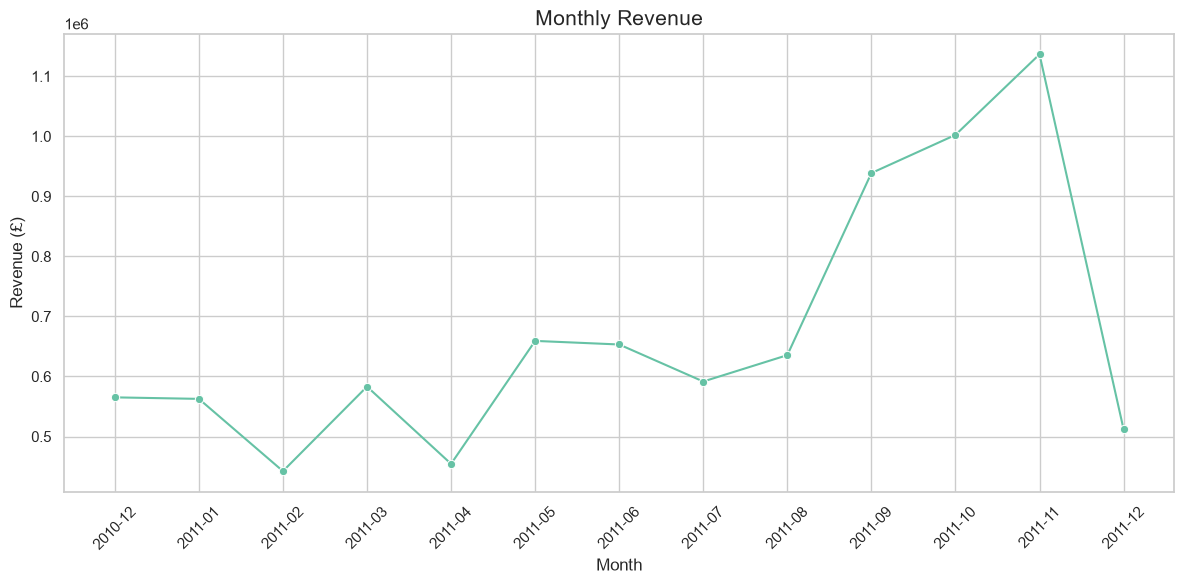

In [77]:
ax = sns.lineplot(data=monthly_summary, x="MonthLabel", y="Revenue", marker="o")
ax.set_title("Monthly Revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Nhận xét:** tháng 11/2011 có doanh thu cao nhất, đạt £1,136,534.00. Tháng 12/2011 chỉ ghi nhận £512,228.08 do dữ liệu mới kéo dài đến ngày 09/12/2011, vì vậy không nên so sánh tháng 12 như một tháng đầy đủ.

Biểu đồ số hóa đơn theo tháng dùng để đối chiếu với doanh thu. Khi doanh thu và số hóa đơn cùng tăng, có thể hiểu là hoạt động mua hàng tăng thật; nếu doanh thu tăng nhưng số hóa đơn không tăng tương ứng, có thể do giá trị đơn hàng lớn hơn.

Đoạn code dưới đây vẽ xu hướng số hóa đơn theo tháng để đối chiếu với biến động doanh thu.

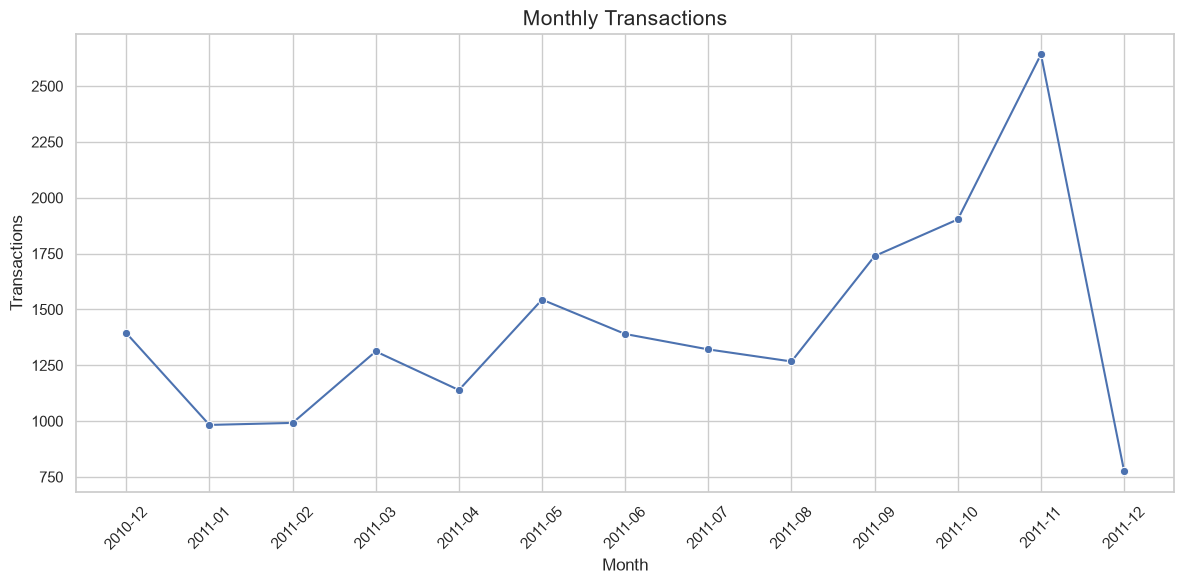

In [78]:
ax = sns.lineplot(data=monthly_summary, x="MonthLabel", y="Transactions", marker="o", color="#4c72b0")
ax.set_title("Monthly Transactions")
ax.set_xlabel("Month")
ax.set_ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Nhận xét:** tháng 11/2011 cũng là tháng có số hóa đơn cao nhất với 2,642 hóa đơn. Tháng 12/2011 có 776 hóa đơn, thấp hơn một phần vì dữ liệu tháng này chưa đủ.

**Nhận xét:** doanh thu và số hóa đơn có xu hướng tăng ở các tháng cuối năm, đặc biệt giai đoạn trước mùa lễ. Riêng tháng `2011-12` cần đọc cẩn thận vì dữ liệu chỉ kéo dài đến `2011-12-09`, nên không đại diện cho cả tháng.

## 5. Product EDA

Phần sản phẩm giúp xác định những mặt hàng đóng góp nhiều doanh thu hoặc bán được số lượng lớn. Hai góc nhìn này không hoàn toàn giống nhau: một sản phẩm có thể bán rất nhiều nhưng đơn giá thấp, hoặc doanh thu cao nhờ giá trị mỗi lần mua lớn.

Bảng sản phẩm tổng hợp doanh thu, số lượng bán và số hóa đơn có phát sinh từng sản phẩm. Đây là cách nhìn nhanh để biết sản phẩm nào có vai trò lớn nhất trong kết quả kinh doanh.

Đoạn code dưới đây tổng hợp dữ liệu theo sản phẩm, gồm doanh thu, số lượng bán và số hóa đơn có phát sinh sản phẩm đó.

In [79]:
product_summary = (
    df.groupby(["StockCode", "Description"])
    .agg(
        Revenue=("TotalPrice", "sum"),
        Quantity=("Quantity", "sum"),
        Transactions=("InvoiceNo", "nunique"),
    )
    .sort_values("Revenue", ascending=False)
)

product_summary.head(10).round(2)

,,Revenue,Quantity,Transactions
StockCode,Description,,,
23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
22423,REGENCY CAKESTAND 3 TIER,142264.75,12374,1703
85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.10,36706,1971
85099B,JUMBO BAG RED RETROSPOT,85040.54,46078,1600
23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195
47566,PARTY BUNTING,68785.23,15279,1379
84879,ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263,1375
23084,RABBIT NIGHT LIGHT,51251.24,27153,801
79321,CHILLI LIGHTS,46265.11,9646,519


Biểu đồ top sản phẩm theo doanh thu cho biết các mặt hàng đóng góp nhiều tiền nhất. Những sản phẩm này thường là nhóm cần được ưu tiên trong quản lý tồn kho, trưng bày hoặc chiến dịch bán hàng.

Đoạn code dưới đây vẽ top 10 sản phẩm theo doanh thu để xác định các mặt hàng đóng góp nhiều tiền nhất.

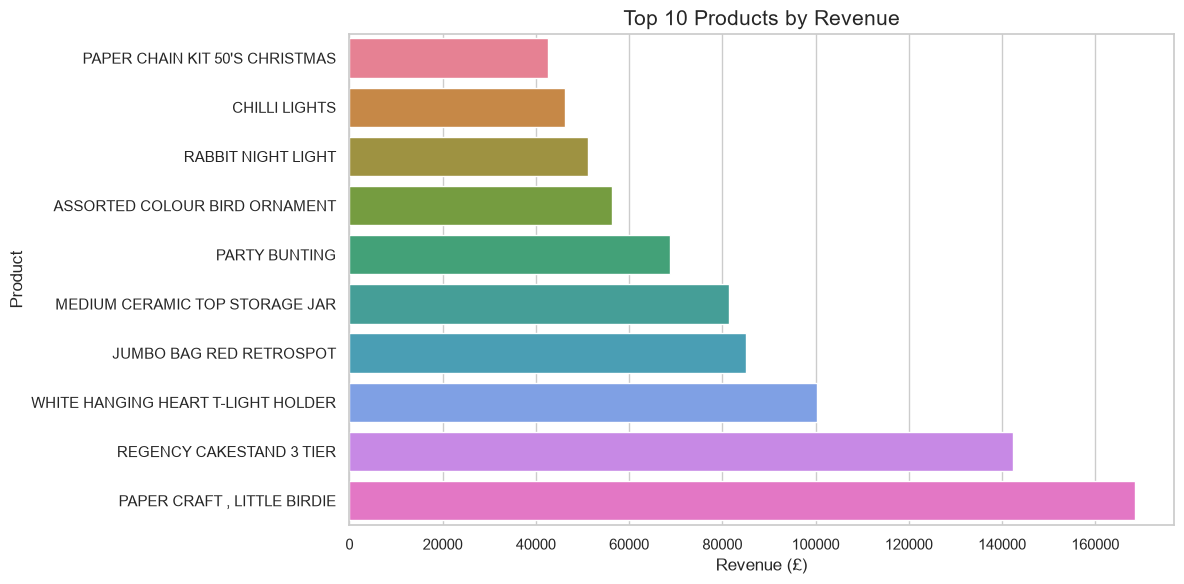

In [80]:
top_products_revenue = product_summary.head(10).reset_index().sort_values("Revenue")

ax = sns.barplot(
    data=top_products_revenue,
    x="Revenue",
    y="Description",
    hue="Description",
    dodge=False,
    legend=False,
)
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue (£)")
ax.set_ylabel("Product")
plt.tight_layout()
plt.show()

**Nhận xét:** sản phẩm có doanh thu cao nhất là `PAPER CRAFT , LITTLE BIRDIE` với £168,469.60. Tiếp theo là `REGENCY CAKESTAND 3 TIER` với £142,264.75 và `WHITE HANGING HEART T-LIGHT HOLDER` với £100,392.10.

Biểu đồ top sản phẩm theo số lượng bán giúp nhìn theo góc độ nhu cầu. Nếu một sản phẩm bán số lượng rất cao nhưng doanh thu không đứng đầu, có thể sản phẩm đó có đơn giá thấp hoặc thường được mua theo lô lớn.

Đoạn code dưới đây vẽ top 10 sản phẩm theo số lượng bán để nhìn ra các sản phẩm có nhu cầu cao nhất.

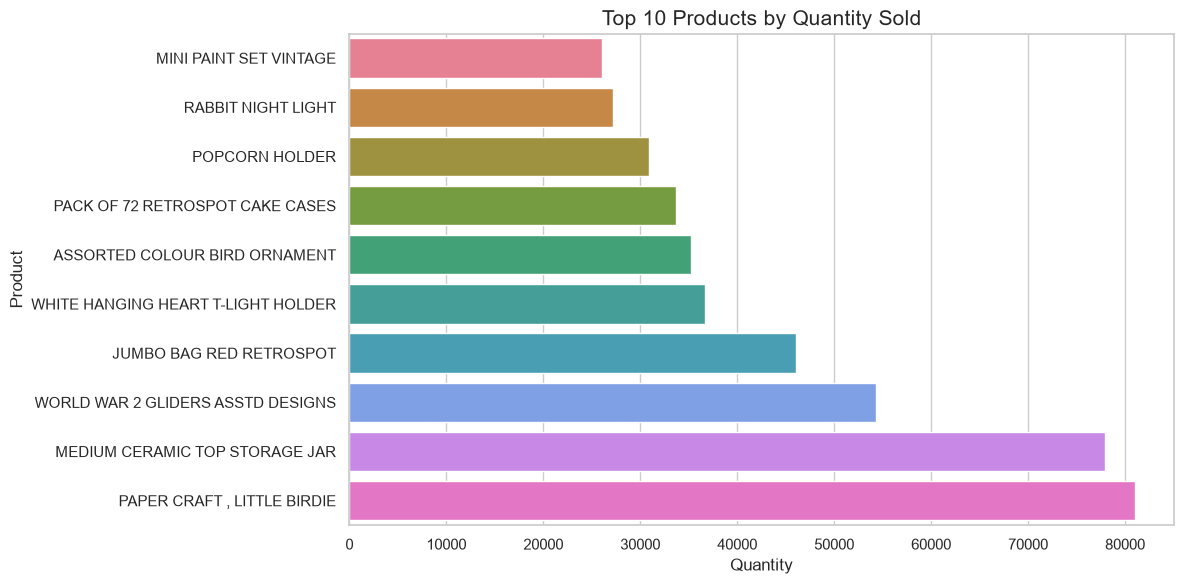

In [81]:
top_products_quantity = product_summary.sort_values("Quantity", ascending=False).head(10).reset_index().sort_values("Quantity")

ax = sns.barplot(
    data=top_products_quantity,
    x="Quantity",
    y="Description",
    hue="Description",
    dodge=False,
    legend=False,
)
ax.set_title("Top 10 Products by Quantity Sold")
ax.set_xlabel("Quantity")
ax.set_ylabel("Product")
plt.tight_layout()
plt.show()

**Nhận xét:** sản phẩm bán nhiều nhất theo số lượng là `PAPER CRAFT , LITTLE BIRDIE` với 80,995 sản phẩm. `MEDIUM CERAMIC TOP STORAGE JAR` đứng thứ hai với 77,916 sản phẩm.

**Nhận xét:** phân tích sản phẩm giúp bổ sung bối cảnh cho doanh thu tổng thể. Tuy nhiên, vì mục tiêu chính của dự án là phân nhóm khách hàng, phần sản phẩm được dùng như phân tích nền thay vì đưa trực tiếp vào GMM.

## 6. Customer EDA

Phần khách hàng giúp nhận diện mức độ tập trung doanh thu và hành vi mua lặp lại. Đây là cầu nối trực tiếp sang RFM, vì RFM cũng tổng hợp dữ liệu giao dịch về cấp độ từng khách hàng.

Bảng dưới đây tổng hợp doanh thu, số hóa đơn, số lượng sản phẩm đã mua và ngày mua gần nhất của từng khách hàng. Những khách hàng đứng đầu doanh thu có thể là nhóm bán buôn hoặc khách hàng chiến lược.

Đoạn code dưới đây tổng hợp dữ liệu theo khách hàng, gồm doanh thu, số hóa đơn, số lượng sản phẩm đã mua và ngày mua gần nhất.

In [82]:
customer_summary = (
    df.groupby("CustomerID")
    .agg(
        Revenue=("TotalPrice", "sum"),
        Transactions=("InvoiceNo", "nunique"),
        Quantity=("Quantity", "sum"),
        LastPurchase=("InvoiceDate", "max"),
    )
    .sort_values("Revenue", ascending=False)
)

top_customer_table = customer_summary.head(10).copy()
top_customer_table["LastPurchase"] = top_customer_table["LastPurchase"].dt.strftime("%Y-%m-%d")

top_customer_table.round(2)

,Revenue,Transactions,Quantity,LastPurchase
CustomerID,,,,
14646,279138.02,72,196844,2011-12-08
18102,259657.30,60,64124,2011-12-09
17450,194390.79,46,69973,2011-12-01
16446,168472.50,2,80997,2011-12-09
14911,136161.83,198,80154,2011-12-08
12415,124564.53,20,77373,2011-11-15
14156,116560.08,54,57755,2011-11-30
17511,91062.38,31,64549,2011-12-07
12346,77183.60,1,74215,2011-01-18


Biểu đồ top 10 khách hàng theo doanh thu cho thấy doanh thu có thể tập trung vào một nhóm nhỏ khách hàng giá trị cao. Đây là lý do sau này cần có chỉ số Monetary trong RFM.

Đoạn code dưới đây vẽ top 10 khách hàng theo doanh thu. Đây là cách nhìn nhanh về nhóm khách hàng giá trị cao.

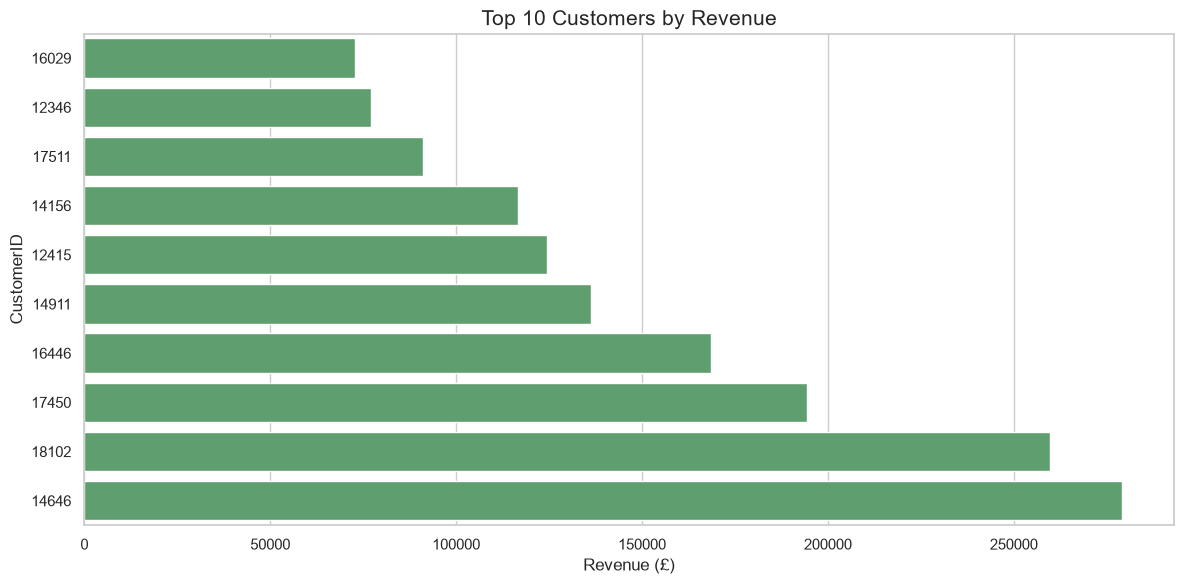

In [83]:
top_customers = customer_summary.head(10).reset_index().sort_values("Revenue")
top_customers["CustomerID"] = top_customers["CustomerID"].astype(str)

ax = sns.barplot(
    data=top_customers,
    x="Revenue",
    y="CustomerID",
    orient="h",
    color="#55a868",
)
ax.set_title("Top 10 Customers by Revenue")
ax.set_xlabel("Revenue (£)")
ax.set_ylabel("CustomerID")
plt.tight_layout()
plt.show()

**Nhận xét:** khách hàng `14646` đứng đầu doanh thu với £279,138.02 và 72 hóa đơn. Khách hàng `18102` đứng thứ hai với £259,657.30 và 60 hóa đơn.

Biểu đồ phân phối số hóa đơn mỗi khách hàng cho thấy phần lớn khách chỉ mua một vài lần, trong khi một số khách quay lại rất nhiều lần. Đây là tín hiệu ban đầu cho thấy Frequency có thể bị lệch phải và cần xử lý kỹ ở bước mô hình.

Đoạn code dưới đây vẽ phân phối số hóa đơn trên mỗi khách hàng để xem đa số khách mua một lần hay quay lại nhiều lần.

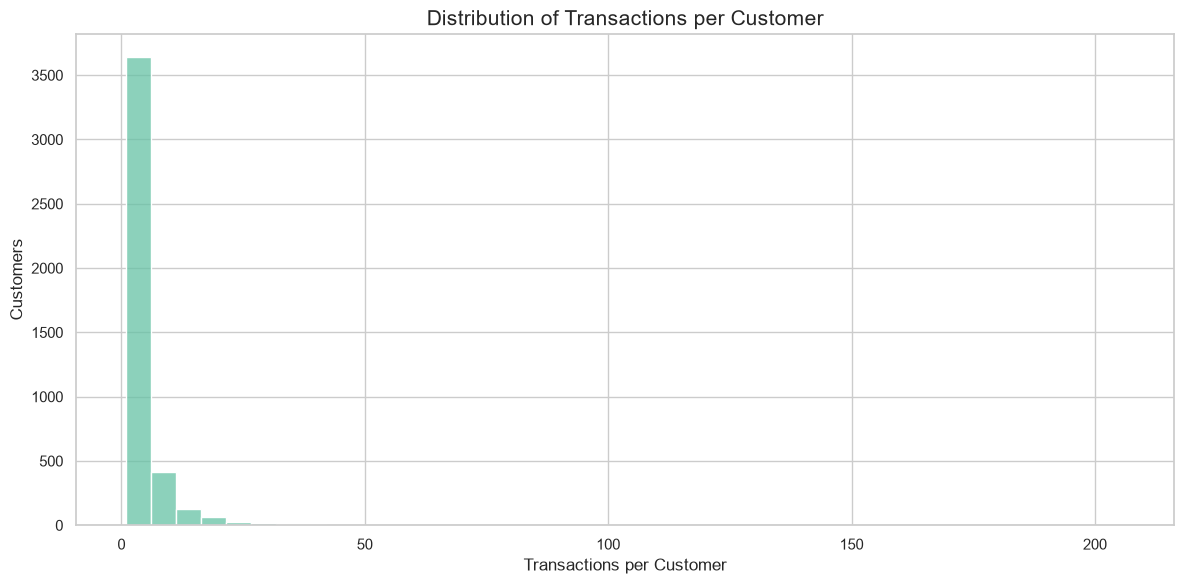

In [84]:
ax = sns.histplot(customer_summary["Transactions"], bins=40, kde=False)
ax.set_title("Distribution of Transactions per Customer")
ax.set_xlabel("Transactions per Customer")
ax.set_ylabel("Customers")
plt.tight_layout()
plt.show()

**Nhận xét:** trung vị số hóa đơn mỗi khách hàng là 2, trong khi phân vị 75% là 5 và giá trị cao nhất là 206 hóa đơn. Điều này cho thấy phần lớn khách mua không quá nhiều lần, nhưng vẫn có một nhóm nhỏ quay lại rất thường xuyên.

Repeat purchase rate đo tỷ lệ khách hàng có từ hai hóa đơn trở lên. Chỉ số này giúp đánh giá mức độ quay lại mua hàng của khách, đồng thời liên hệ trực tiếp với biến Frequency trong RFM.

Đoạn code dưới đây tính repeat purchase rate, tức tỷ lệ khách hàng có từ hai hóa đơn trở lên trên tổng số khách hàng.

In [85]:
repeat_customers = int((customer_summary["Transactions"] >= 2).sum())
total_customers = int(customer_summary.shape[0])
repeat_purchase_rate = repeat_customers / total_customers * 100

repeat_purchase_summary = pd.DataFrame(
    {
        "Metric": ["Total Customers", "Repeat Customers", "Repeat Purchase Rate"],
        "Value": [
            f"{total_customers:,}",
            f"{repeat_customers:,}",
            f"{repeat_purchase_rate:.2f}%",
        ],
    }
)

repeat_purchase_summary

,Metric,Value
0,Total Customers,"4,334"
1,Repeat Customers,"2,829"
2,Repeat Purchase Rate,65.27%


**Nhận xét:** có 2,829 trên 4,334 khách hàng phát sinh từ hai hóa đơn trở lên, tương đương repeat purchase rate 65.27%. Tỷ lệ này cho thấy dữ liệu có đủ nhóm khách mua lặp lại để phân tích RFM.

**Nhận xét:** nếu tỷ lệ mua lại ở mức cao, cửa hàng có một nhóm khách quay lại đáng kể để phân tích sâu hơn. Ở phase RFM, nhóm khách này sẽ được mô tả rõ hơn bằng Frequency, Monetary và Recency.

## 7. EDA Conclusion

Qua EDA, dữ liệu sau làm sạch có cấu trúc ổn định để phân tích tiếp. Các kiểm tra chất lượng dữ liệu không còn ghi nhận giao dịch âm, hóa đơn hủy, khách hàng thiếu mã định danh hoặc tổng tiền không hợp lệ.

Ở cấp độ thị trường, United Kingdom là quốc gia nổi bật nhất nếu xét đồng thời doanh thu, số khách hàng và số hóa đơn. Điều này cho thấy UK không chỉ có doanh thu lớn, mà còn có quy mô khách hàng đủ rộng để xây dựng mô hình phân nhóm có ý nghĩa.

Một số thị trường nhỏ như Netherlands hoặc EIRE có doanh thu trung bình trên mỗi khách hàng cao, nhưng số lượng khách hàng thấp. Các thị trường này có thể đáng chú ý cho chiến lược chăm sóc khách hàng lớn, nhưng chưa phù hợp để làm mô hình GMM riêng trong phạm vi dự án hiện tại.

Vì vậy, phase tiếp theo sẽ tập trung xây dựng bảng RFM cho khách hàng United Kingdom trong toàn bộ giai đoạn dữ liệu, sau đó dùng RFM làm đầu vào cho GMM segmentation.